In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# LOAD DATA
# -----------------------------
df = pd.read_csv(
    "/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/canarywharf_r10_2025-03_04.csv"
)

In [31]:
df = df[df['type'] == 'stop']

In [32]:
df['ts'].head()

0     1743382001
3     1742873344
5     1743333966
8     1743053391
13    1743417802
Name: ts, dtype: int64

In [33]:
# TIME PROCESSING
# -----------------------------
df['ts'] = pd.to_datetime(df['ts'], unit='s')
df['date'] = df['ts'].dt.date
df['hour'] = df['ts'].dt.hour

In [34]:
df['ts'].head()

0    2025-03-31 00:46:41
3    2025-03-25 03:29:04
5    2025-03-30 11:26:06
8    2025-03-27 05:29:51
13   2025-03-31 10:43:22
Name: ts, dtype: datetime64[ns]

*without duration*

In [35]:
# NIGHTTIME FILTER (7 PM – 7 AM)
# -----------------------------
night_df = df[(df['hour'] >= 19) | (df['hour'] < 7)]

In [36]:
# COUNT UNIQUE NIGHTS 
# -----------------------------
resident_counts = (
    night_df.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

In [42]:
# FINAL RESIDENT FILTER
# -----------------------------
residents_5 = resident_counts[resident_counts['nights'] >= 5]['id']
print("Likely residents >=5:", len(residents_5))

residents_4 = resident_counts[resident_counts['nights'] >= 4]['id']
print("Likely residents >=4:", len(residents_4))

residents_3 = resident_counts[resident_counts['nights'] >= 3]['id']
print("Likely residents >=3:", len(residents_3))

residents_2 = resident_counts[resident_counts['nights'] >= 2]['id']
print("Likely residents >=2:", len(residents_2))


Likely residents >=5: 4568
Likely residents >=4: 6788
Likely residents >=3: 11307
Likely residents >=2: 23286


*with duration*

In [44]:
# -----------------------------
# DURATION CALCULATION (ADD-ON)
# -----------------------------

duration_df = (
    night_df.groupby(['id', 'date'])
    .agg(
        start_time=('ts', 'min'),
        end_time=('ts', 'max'),
        num_points=('ts', 'count')
    )
    .reset_index()
)

duration_df['duration_hours'] = (
    duration_df['end_time'] - duration_df['start_time']
).dt.total_seconds() / 3600

In [54]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 2
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_5_dur2 = resident_counts_dur[resident_counts_dur['nights'] >= 5]['id']
print("users with at least 2 observations per night across at least 5 nights:", len(residents_5_dur2))

users with at least 2 observations per night across at least 5 nights: 3107


In [56]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 3
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_5_dur3 = resident_counts_dur[resident_counts_dur['nights'] >= 5]['id']
print("users with at least 3 observations per night across at least 5 nights:", len(residents_5_dur3))

users with at least 3 observations per night across at least 5 nights: 2307


In [57]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 2
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_7_dur2 = resident_counts_dur[resident_counts_dur['nights'] >= 7]['id']
print("users with at least 2 observations per night across at least 7 nights:", len(residents_7_dur2))

users with at least 2 observations per night across at least 7 nights: 1679


In [60]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 3
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_7_dur3 = resident_counts_dur[resident_counts_dur['nights'] >= 7]['id']
print("users with at least 3 observations per night across at least 7 nights:", len(residents_7_dur3))

users with at least 3 observations per night across at least 7 nights: 1237


*duration per week, hrs per night*

In [61]:
duration_df['night_date'] = duration_df['date']

duration_df.loc[duration_df['start_time'].dt.hour < 7, 'night_date'] = (
    duration_df['night_date'] - pd.Timedelta(days=1))

In [72]:
duration_df['week'] = pd.to_datetime(duration_df['night_date']).dt.to_period('W')

# Parameters to test
hour_thresholds = [5, 7]
night_thresholds = [2, 3]

for hrs in hour_thresholds:
    for nights in night_thresholds:
        
        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]
        
        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )
        
        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        
        # unique users
        users = weekly_valid['id'].unique()
        
        print(f"Users ≥{hrs}hrs/night & ≥{nights} nights/week:", len(users))

Users ≥5hrs/night & ≥2 nights/week: 1557
Users ≥5hrs/night & ≥3 nights/week: 508
Users ≥7hrs/night & ≥2 nights/week: 1385
Users ≥7hrs/night & ≥3 nights/week: 447


In [76]:
duration_df['week'] = pd.to_datetime(duration_df['night_date']).dt.to_period('W')

# Parameters to test
hour_thresholds = [2,5,7]
night_thresholds = [2, 3]

for hrs in hour_thresholds:
    for nights in night_thresholds:
        
        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]
        
        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )
        
        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        
        # unique users
        users = weekly_valid['id'].unique()
        
        print(f"Users ≥{hrs}hrs/night & ≥{nights} nights/week:", len(users))

Users ≥2hrs/night & ≥2 nights/week: 2814
Users ≥2hrs/night & ≥3 nights/week: 875
Users ≥5hrs/night & ≥2 nights/week: 1557
Users ≥5hrs/night & ≥3 nights/week: 508
Users ≥7hrs/night & ≥2 nights/week: 1385
Users ≥7hrs/night & ≥3 nights/week: 447


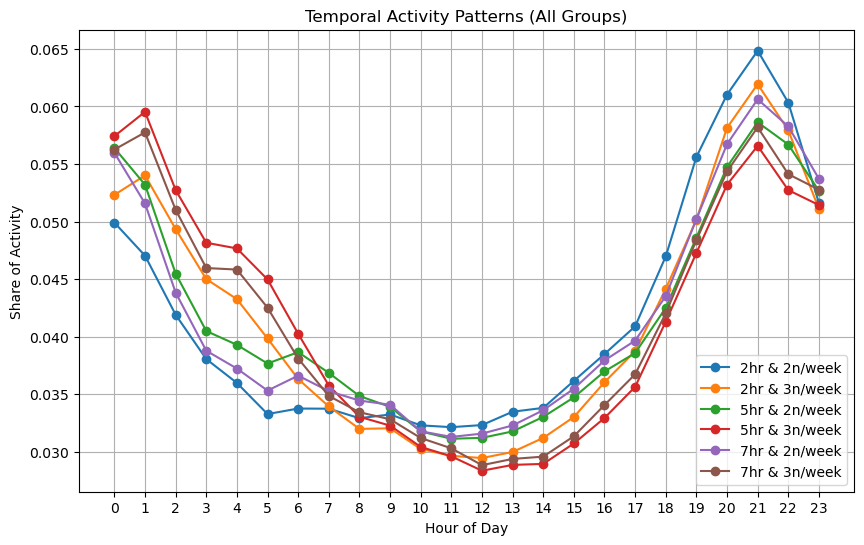

In [77]:
import matplotlib.pyplot as plt

# parameters
hour_thresholds = [2, 5, 7]
night_thresholds = [2, 3]

plt.figure(figsize=(10,6))

for hrs in hour_thresholds:
    for nights in night_thresholds:

        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]

        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )

        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]

        # get users
        users = weekly_valid['id'].unique()

        # filter original data
        temp_df = df[df['id'].isin(users)]

        # hourly activity
        hourly = (
            temp_df.groupby('hour')
            .size()
            .reset_index(name='count')
        )

        # normalize
        hourly['normalized'] = hourly['count'] / hourly['count'].sum()

        # label
        label = f"{hrs}hr & {nights}n/week"

        plt.plot(hourly['hour'], hourly['normalized'], marker='o', label=label)

# plot settings
plt.xlabel("Hour of Day")
plt.ylabel("Share of Activity")
plt.title("Temporal Activity Patterns (All Groups)")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)
plt.show()

In [81]:
!pip install matplotlib-venn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 KB 1.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 43.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 22.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.4 MB/s eta 0:00:0000:01:00:01
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45301 sha256=2e181707bae308b8547bbb3a49a2f417adc1e7d6bc2e2

In [82]:
user_sets = {}

for hrs in [2, 7]:
    for nights in [2, 3]:

        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]

        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )

        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        users = set(weekly_valid['id'].unique())

        key = f"{hrs}hr_{nights}n"
        user_sets[key] = users

In [83]:
set1 = user_sets['7hr_2n']
set2 = user_sets['2hr_3n']
set3 = user_sets['7hr_3n']

In [84]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

venn3(
    [set1, set2, set3],
    set_labels=('7hr & 2n', '2hr & 3n', '7hr & 3n')
)

plt.title("Overlap of Resident Definitions")
plt.show()

ModuleNotFoundError: No module named 'matplotlib_venn'

In [85]:
# define sets
A = user_sets['7hr_2n']
B = user_sets['2hr_3n']
C = user_sets['7hr_3n']

# sizes
print("A (7hr & 2n):", len(A))
print("B (2hr & 3n):", len(B))
print("C (7hr & 3n):", len(C))

# overlaps
print("A ∩ B:", len(A & B))
print("A ∩ C:", len(A & C))
print("B ∩ C:", len(B & C))
print("A ∩ B ∩ C:", len(A & B & C))

A (7hr & 2n): 1385
B (2hr & 3n): 875
C (7hr & 3n): 447
A ∩ B: 688
A ∩ C: 447
B ∩ C: 447
A ∩ B ∩ C: 447


# LSOA BREAKDOWN

In [90]:
print(duration_df.columns)

Index(['id', 'date', 'start_time', 'end_time', 'num_points', 'duration_hours',
       'night_date', 'week'],
      dtype='object')


In [91]:
print(df.columns)

Index(['id', 'lat', 'lon', 'ts', 'date', 'gridcell', 'type', 'hour'], dtype='object')


In [92]:
night_data = df[(df['hour'] >= 19) | (df['hour'] < 7)].copy()

# Round coordinates
night_data['lat_round'] = night_data['lat'].round(4)
night_data['lon_round'] = night_data['lon'].round(4)

# Count frequency
home_counts = (
    night_data
    .groupby(['id', 'lat_round', 'lon_round'])
    .size()
    .reset_index(name='count')
)

# Get dominant home per user
home_df = (
    home_counts
    .sort_values(['id', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['id'])
)

home_df = home_df.rename(columns={
    'lat_round': 'home_lat',
    'lon_round': 'home_lon'
})

home_df = home_df[['id', 'home_lat', 'home_lon']]

print("Home locations:", len(home_df))

Home locations: 73536


In [93]:
temp = duration_df[
    (duration_df['duration_hours'] >= 3) &
    (duration_df['num_points'] >= 2)
]

weekly = (
    temp.groupby(['id', 'week'])['night_date']
    .nunique()
    .reset_index(name='nights_per_week')
)

weekly_valid = weekly[weekly['nights_per_week'] >= 3]

residents_700_ids = weekly_valid['id'].unique()

print("Residents (700 group):", len(residents_700_ids))

Residents (700 group): 700


In [94]:
home_700 = home_df[home_df['id'].isin(residents_700_ids)].copy()

In [95]:
import geopandas as gpd

home_700_gdf = gpd.GeoDataFrame(
    home_700,
    geometry=gpd.points_from_xy(home_700['home_lon'], home_700['home_lat']),
    crs="EPSG:4326"
)

In [99]:
import geopandas as gpd

lsoa_path = "/green-projects/project-urban_colocation_intelligence/workspace/share/data/boundary/London_LSOA_2021/origdata/LB_shp"

lsoa_gdf = gpd.read_file(lsoa_path, layer="Tower Hamlets")

print("LSOA loaded:", len(lsoa_gdf))
print(lsoa_gdf.columns)

LSOA loaded: 169
Index(['lsoa21cd', 'lsoa21nm', 'msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm',
       'geometry'],
      dtype='object')


In [101]:
cw_lsoas = ["E01004277", "E01032771", "E01032780", "E01032782"]

cw_lsoa_gdf = lsoa_gdf[lsoa_gdf["lsoa21cd"].isin(cw_lsoas)].copy()
cw_lsoa_gdf = cw_lsoa_gdf.to_crs("EPSG:4326")

In [102]:
print("CW LSOAs loaded:", len(cw_lsoa_gdf))

CW LSOAs loaded: 4


In [103]:
residents_700_lsoa = gpd.sjoin(
    home_700_gdf,
    cw_lsoa_gdf,
    how="inner",
    predicate="within"
)

In [104]:
lsoa_counts_700 = (
    residents_700_lsoa
    .groupby("lsoa21cd")["id"]
    .nunique()
    .reset_index()
    .rename(columns={"id": "resident_count"})
)

print(lsoa_counts_700)

    lsoa21cd  resident_count
0  E01004277             476
1  E01032771             117
2  E01032780              40
3  E01032782               8


In [113]:
inside_700 = lsoa_counts_700["resident_count"].sum()
total_700 = len(residents_700_ids)

print("\n--- SUMMARY ---")
print("Total residents:", total_700)
print("Inside LSOA boundary:", inside_700)
print("Outside LSOA boundary:", total_700 - inside_700)
print("Inside %:", round((inside_700 / total_700) * 100, 2), "%")


--- SUMMARY ---
Total residents: 700
Inside LSOA boundary: 641
Outside LSOA boundary: 59
Inside %: 91.57 %
